In [1]:
import numpy as np
import pandas as pd

In [2]:
import tensorflow
import keras
from keras.layers import Dense
from keras import Sequential

In [5]:
df = pd.read_csv('2-Social_Network_Ads.csv')

In [8]:
df.head(3)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0


In [9]:
df = df.drop(columns=['User ID','Gender'])

In [10]:
df.head(4)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0


In [12]:
df.shape

(400, 3)

In [11]:
model = Sequential()

In [13]:
model.add(Dense(128,activation="relu",input_dim=2))
model.add(Dense(1,activation="sigmoid"))

D:\Deep_Learning\.venv_tf1\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train,X_test,y_train,y_test= train_test_split(df.iloc[:,:-1],df.iloc[:,-1],test_size=0.2,random_state=30)

In [18]:
X_train.shape

(320, 2)

In [19]:
import matplotlib.pyplot as plt

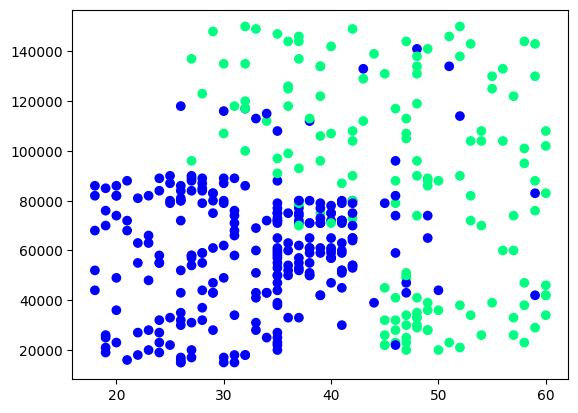

In [21]:
plt.scatter(df.iloc[:,0],df.iloc[:,1],c=df.iloc[:,-1],cmap="winter")

In [22]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=80,verbose=1)

Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.3721 - loss: 3479.4326 - val_accuracy: 0.6125 - val_loss: 728.4244
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6163 - loss: 985.2993 - val_accuracy: 0.6125 - val_loss: 411.2900
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4912 - loss: 265.8779 - val_accuracy: 0.6125 - val_loss: 202.3492
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6015 - loss: 200.1070 - val_accuracy: 0.3875 - val_loss: 69.6483
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5665 - loss: 98.3957 - val_accuracy: 0.6125 - val_loss: 49.3927
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5724 - loss: 64.1649 - val_accuracy: 0.6125 - val_loss: 140.0421
Epoch 7/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5148 - loss: 137.9325 - val_accuracy: 0.6125 - val_loss: 247.5872
Epoch 8/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5467 - loss: 183.8083

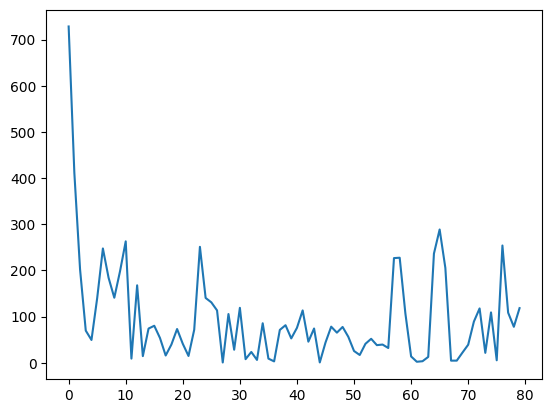

In [23]:
plt.plot(history.history['val_loss'],label='test')

## Applying Standard Scaler

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()

In [26]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
mod = Sequential()

In [29]:
mod.add(Dense(128,activation="relu",input_dim=2))
mod.add(Dense(1,activation="sigmoid"))

D:\Deep_Learning\.venv_tf1\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])
history = model.fit(X_train_scaled,y_train,validation_data=(X_test_scaled,y_test),epochs=80,verbose=1)

Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.6116 - loss: 0.7277 - val_accuracy: 0.6125 - val_loss: 0.6769
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6380 - loss: 0.6462 - val_accuracy: 0.6125 - val_loss: 0.6129
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6941 - loss: 0.5740 - val_accuracy: 0.7000 - val_loss: 0.5559
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7656 - loss: 0.5300 - val_accuracy: 0.7500 - val_loss: 0.5055
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7636 - loss: 0.4930 - val_accuracy: 0.7875 - val_loss: 0.4617
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8079 - loss: 0.4493 - val_accuracy: 0.8375 - val_loss: 0.4233
Epoch 7/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8339 - loss: 0.4324 - val_accuracy: 0.8875 - val_loss: 0.3918
Epoch 8/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8614 - loss: 0.3922 - val_accuracy: 0.8875 - v

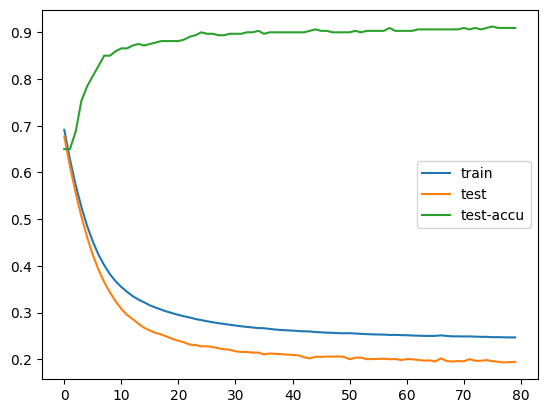

In [34]:
plt.plot(history.history['loss'],label="train")
plt.plot(history.history['val_loss'],label='test')
plt.plot(history.history['accuracy'],label='test-accu')
plt.legend()
plt.show()

### Accuracy Increased after the scaling